# Topology tests — winding number and Chern marker

Real-space topological invariants computed via `get_W` (1D winding number)
and `get_C` (2D Chern marker).  Both functions auto-derive their coordinate
functions from `H.geometry_uc` and build the position / σₓ operators
automatically for sublattice models.

In [4]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding
using QuanticsTCI
import TensorCrossInterpolation as TCI

## 1. SSH chain — real-space winding number

The SSH model has two sublattice atoms per unit cell with hoppings

    t₁ = t + δ   (intra-cell)
    t₂ = t − δ   (inter-cell)

- **δ < 0** ( t₂ > t₁ ): topological phase, winding number **W = 1**
- **δ > 0** ( t₁ > t₂ ): trivial phase, winding number **W = 0**

We sweep δ/t across the transition and evaluate the real-space winding-number
marker `get_W(H)` at the central unit cell.
`σ_z` and `xfunc` are both auto-derived from `H.geometry_uc`.

In [8]:
L_ssh = 6            # 2⁴ = 16 unit cells, 32 physical sites
t0    = 1.0
Ncheb = 150
mdim  = 60

# δ/t sweep: skip |δ| < 0.05 where the gap closes
deltas = vcat(range(-0.85, 0.85; length=50))
W_vals = Float64[]

for d in deltas
    H    = TensorBinding.get_Hamiltonian("ssh_sublattice", (t=t0, d=d); L=L_ssh)
    W_cl = TensorBinding.get_W(H; method=:mcweeny, maxdim=mdim,
                                 l=L_ssh, Λ=10)
    uc_c = H.N ÷ 2 + 1   # centre unit cell (1-indexed)
    push!(W_vals, real(W_cl(uc_c)))
    println("δ = ", lpad(round(d; digits=3), 6), "   W = ", round(W_vals[end]; digits=4))
end

δ =  -0.85   W = -0.9985
δ = -0.815   W = -0.9972
δ = -0.781   W = -0.9982
δ = -0.746   W = -0.9974
δ = -0.711   W = -0.9983
δ = -0.677   W = -0.9968
δ = -0.642   W = -0.9979
δ = -0.607   W = -0.9967
δ = -0.572   W = -0.9975
δ = -0.538   W = -0.9978
δ = -0.503   W = -0.9978
δ = -0.468   W = -0.9982
δ = -0.434   W = -0.9975
δ = -0.399   W = -0.998
δ = -0.364   W = -0.9973
δ =  -0.33   W = -0.997
δ = -0.295   W = -0.9966
δ =  -0.26   W = -0.9961
δ = -0.226   W = -0.9962
δ = -0.191   W = -0.9948
δ = -0.156   W = -0.9929
δ = -0.121   W = -0.9905
δ = -0.087   W = -0.9856
δ = -0.052   W = -0.9615
δ = -0.017   W = -0.6499
δ =  0.017   W = -0.1024
δ =  0.052   W = -0.02
δ =  0.087   W = -0.0063
δ =  0.121   W = -0.003
δ =  0.156   W = -0.0012
δ =  0.191   W = -0.0009
δ =  0.226   W = -0.0002
δ =   0.26   W = -0.0003
δ =  0.295   W = -0.0002
δ =   0.33   W = -0.0001
δ =  0.364   W = -0.0001
δ =  0.399   W = -0.0
δ =  0.434   W = 0.0001
δ =  0.468   W = 0.0
δ =  0.503   W = -0.0001
δ =  0.538   

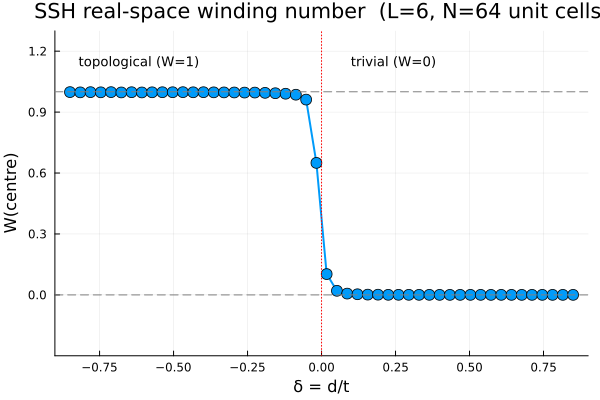

In [9]:
p = plot(deltas, -W_vals;
         xlabel="δ = d/t",
         ylabel="W(centre)",
         title="SSH real-space winding number  (L=$L_ssh, N=$(2^L_ssh) unit cells)",
         lw=2, marker=:circle, markersize=6, legend=false,
         ylims=(-0.3, 1.3))
hline!([0.0, 1.0]; linestyle=:dash, color=:gray, lw=1)
vline!([0.0];      linestyle=:dot,  color=:red,  lw=1)
annotate!(-0.82, 1.15, text("topological (W=1)", 9, :left))
annotate!( 0.10, 1.15, text("trivial (W=0)",     9, :left))
p

## 2. Haldane model — real-space Chern marker

Honeycomb lattice with nearest-neighbour (NN) hopping t₁ and complex
next-nearest-neighbour (NNN) hoppings t₂ e^{±iφ} (Haldane 1988).
At φ = π/2 and t₂/t₁ small the system is a Chern insulator with **|C| = 1**.

We build the model exactly as in `test_geometries` and then compute the
real-space Chern marker `get_C(H)` at the central unit cell.
`xfunc` and `yfunc` are auto-derived from `H.geometry_uc`.

In [8]:
Lx_h, Ly_h   = 4, 4
t1, t2, phi  = 1.0, 0.1, pi/2

H_hald = TensorBinding.get_Hamiltonian("honeycomb", (t=t1,);
                                        L=Lx_h+Ly_h, Lx=Lx_h, Ly=Ly_h)

# Six canonical NNN bonds: A→A (+φ), B→B (−φ)
# Phase signs determined by the Haldane chirality convention
haldane_phases = Dict(
    (1, 0,1,1) =>  1,   (0, 1,1,1) => -1,   (1,-1,1,1) => -1,
    (1, 0,2,2) => -1,   (0, 1,2,2) =>  1,   (1,-1,2,2) =>  1,
)
TensorBinding.add_hopping_2D!(H_hald,
    (dx,dy,fs,ts) -> t2 * exp(im * phi * get(haldane_phases, (dx,dy,fs,ts), 0));
    Lx=Lx_h, Ly=Ly_h, nn=2)

TBHamiltonian | L=8, N=256 +2sublattices, scale=auto, maxlinkdim=7 | geometry: 256 sites, 2D | no Tn cache

In [ ]:
M_hald = TensorBinding.get_matrix(H_hald.mpo, H_hald.sites)
println("max |M − M†| = ", maximum(abs.(M_hald - M_hald')))

function geometry_matrix(H)
    n_sub   = H.sublattice_s === nothing ? 1 : ITensors.dim(H.sublattice_s)
    N_atoms = n_sub * H.N
    rs      = Matrix{Float64}(undef, N_atoms, 2)
    for i in 1:N_atoms; rs[i, :] = H.geometry(i); end
    return rs
end

function plot_bonds_physical(M, rs; title="", threshold=0.3, simplify=true, n_sub=1)
    xs_p = rs[:, 1]
    ys_p = rs[:, 2]
    N    = size(rs, 1)
    plt  = plot(; title=title, aspect_ratio=:equal, legend=false, axis=false, grid=false)
    use_arrows = maximum(abs.(imag.(M))) > 1e-3
    sub_colors = [:darkorange, :mediumpurple, :seagreen, :crimson]
    for i in 1:N, j in i+1:N
        mij = M[i, j]
        abs(mij) > threshold || continue
        xi, yi = xs_p[i], ys_p[i]
        xj, yj = xs_p[j], ys_p[j]
        plot!(plt, [xi, xj], [yi, yj]; color=:gray, linewidth=2, alpha=0.8)
        if use_arrows && abs(imag(mij)) > 1e-4
            si = ((i-1) % n_sub) + 1
            sj = ((j-1) % n_sub) + 1
            col = (n_sub > 1 && si == sj) ? sub_colors[si] : :darkorange
            dx, dy = imag(mij) > 0 ? (xi - xj, yi - yj) : (xj - xi, yj - yi)
            blen  = sqrt(dx^2 + dy^2)
            ux, uy = dx/blen, dy/blen
            half   = blen * 0.22
            mx, my = (xi + xj)/2, (yi + yj)/2
            plot!(plt, [mx - half*ux, mx + half*ux], [my - half*uy, my + half*uy];
                  color=col, linewidth=2.5, alpha=0.95, arrow=true)
        end
    end
    scatter!(plt, xs_p, ys_p;
             markersize=simplify ? 10 : 4, color=:steelblue,
             markerstrokecolor=:white, markerstrokewidth=1.5)
    return plt
end

p1 = plot_bonds_physical(M_hald, geometry_matrix(H_hald);
         simplify=false, threshold=0.05, n_sub=2, title="Haldane Re(H)")

In [11]:
# Central unit cell: (ix, iy) = (Lx_uc÷2, Ly_uc÷2) in row-major layout
Lx_uc    = 2^Lx_h                                 # 4 UCs along x
Ly_uc    = 2^Ly_h                                 # 4 UCs along y
n_cell_c = (Ly_uc ÷ 2) * Lx_uc + (Lx_uc ÷ 2)    # 0-indexed UC number
uc_c_hald = n_cell_c + 1                          # 1-indexed UC number
mdim_h = 500

println("Centre UC: ", n_cell_c, "  (ix=", n_cell_c % Lx_uc, ", iy=", n_cell_c ÷ Lx_uc, ")")
println("Centre position: ", round.(H_hald.geometry_uc(n_cell_c * 2 + 1); digits=3))

C_at     = TensorBinding.get_C(H_hald; method=:mcweeny,
                                maxdim=mdim_h, l=Lx_h, Λ=10)
C_center = real(C_at(uc_c_hald))
println("
Chern marker at centre: ", round(C_center; digits=4),
        "   (expected ≈ ±1 for Haldane topological phase)")

Centre UC: 136  (ix=8, iy=8)
Centre position: [12.0, 6.928]
Quenched operator products done
C1 done
C2 done
C3 done
C4 done

Chern marker at centre: 1.0633   (expected ≈ ±1 for Haldane topological phase)


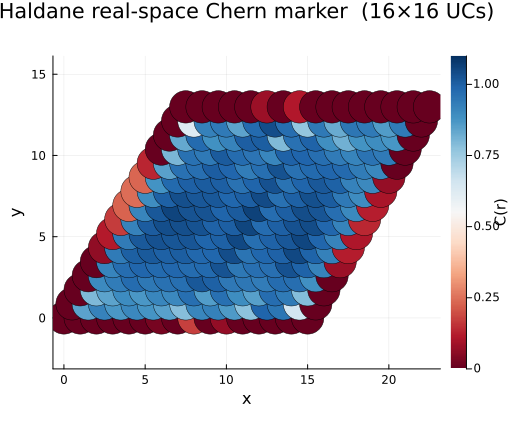

In [12]:
# Real-space Chern marker map over all unit cells
N_uc = 2^(Lx_h + Ly_h)   # 16 UCs for Lx_h=Ly_h=2

# UC uc (1-indexed) -> A-sublattice physical site -> Bravais position
uc_pos  = [H_hald.geometry_uc((uc - 1) * 2 + 1) for uc in 1:N_uc]
C_vals  = [real(C_at(uc)) for uc in 1:N_uc]

xs = [p[1] for p in uc_pos]
ys = [p[2] for p in uc_pos]

scatter(xs, ys;
    marker_z          = C_vals,
    color             = :RdBu,
    markersize        = 18,
    markerstrokewidth = 0.5,
    markerstrokecolor = :black,
    colorbar          = true,
    colorbar_title    = "C(r)",
    clims             = (0., 1.1),
    aspect_ratio      = :equal,
    legend            = false,
    title             = "Haldane real-space Chern marker  ($(2^Lx_h)×$(2^Ly_h) UCs)",
    xlabel            = "x",
    ylabel            = "y",
    size              = (520, 440))